Matplotlib ofrece soporte para gráficos 3D mediante subplot_kw={"projection": "3d"}. Con NumPy generamos datos y desde Matplotlib los visualizamos con dispersión, superficies y triangulaciones.

11.1 Importación de mpl_toolkits.mplot3d
Desde Matplotlib moderno basta con crear el subplot con proyección 3D, sin importar Axes3D explícitamente.

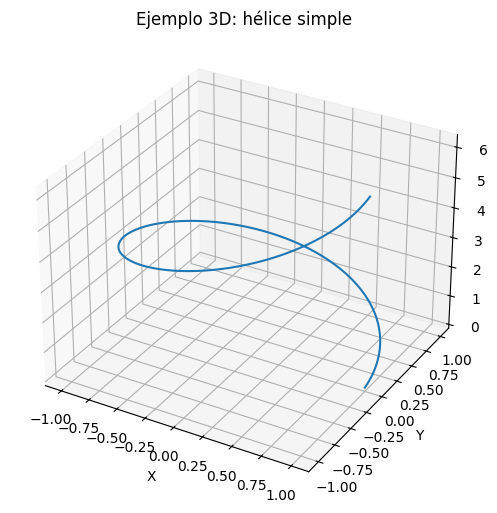

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 5), layout="constrained")

t = np.linspace(0, 2 * np.pi, 200)
x, y, z = np.cos(t), np.sin(t), t

ax.plot3D(x, y, z)
ax.set_title("Ejemplo 3D: hélice simple")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

11.2 Gráficos de dispersión y superficie en 3D
Dispersión 3D (ax.scatter)

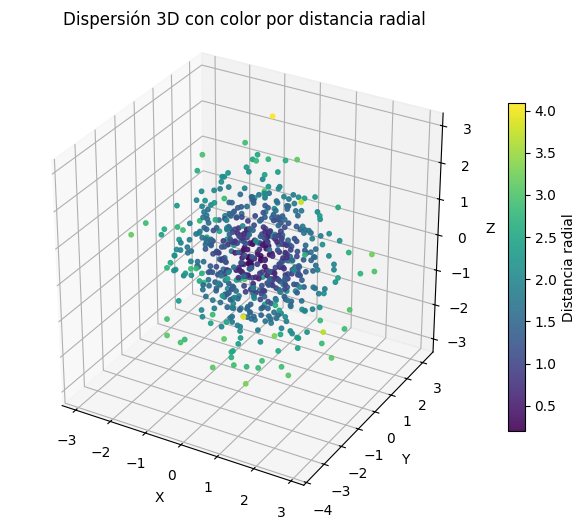

In [2]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
n = 600
x = rng.normal(0, 1, n)
y = rng.normal(0, 1, n)
z = rng.normal(0, 1, n)
c = np.sqrt(x**2 + y**2 + z**2)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 5), layout="constrained")
sc = ax.scatter(x, y, z, c=c, cmap="viridis", s=10, alpha=0.9)

ax.set_title("Dispersión 3D con color por distancia radial")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.05)
cb.set_label("Distancia radial")
ax.set_box_aspect((1, 1, 1))
plt.show()

💡 Usá alpha moderado y set_box_aspect para evitar distorsiones.

Superficie en malla regular (ax.plot_surface)

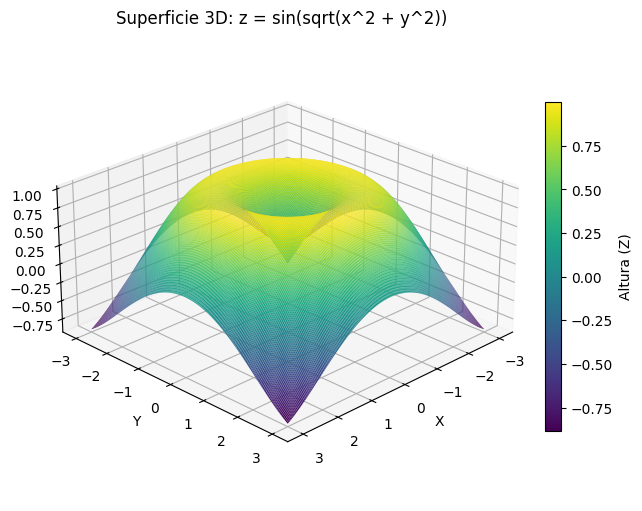

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 5), layout="constrained")

surf = ax.plot_surface(X, Y, Z, cmap="viridis", rstride=1, cstride=1, linewidth=0, antialiased=True)

ax.set_title("Superficie 3D: z = sin(sqrt(x^2 + y^2))")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

cb = fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.05)
cb.set_label("Altura (Z)")
ax.view_init(elev=25, azim=45)
ax.set_box_aspect((1, 1, 0.5))
plt.show()

Superficie con datos dispersos (ax.plot_trisurf)

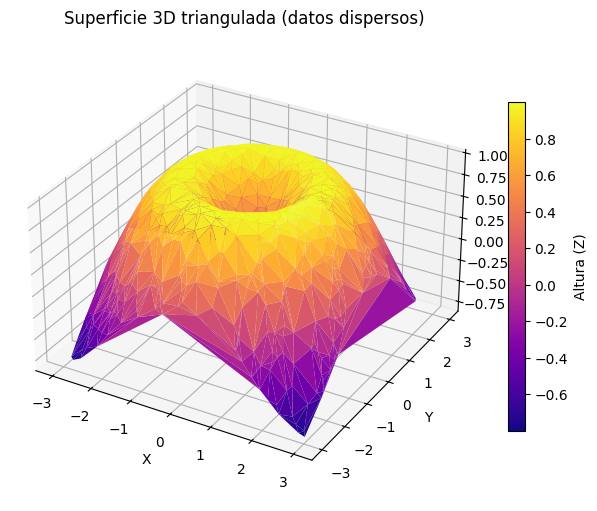

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation

rng = np.random.default_rng(0)
n = 800
x = 6 * rng.random(n) - 3
y = 6 * rng.random(n) - 3
z = np.sin(np.sqrt(x**2 + y**2))

tri = Triangulation(x, y)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 5), layout="constrained")
surf = ax.plot_trisurf(tri, z, cmap="plasma", linewidth=0.2, antialiased=True)

ax.set_title("Superficie 3D triangulada (datos dispersos)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.05).set_label("Altura (Z)")
ax.set_box_aspect((1, 1, 0.6))
plt.show()

Variantes rápidas

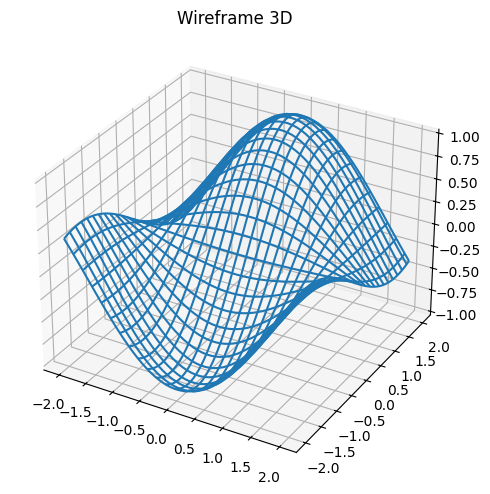

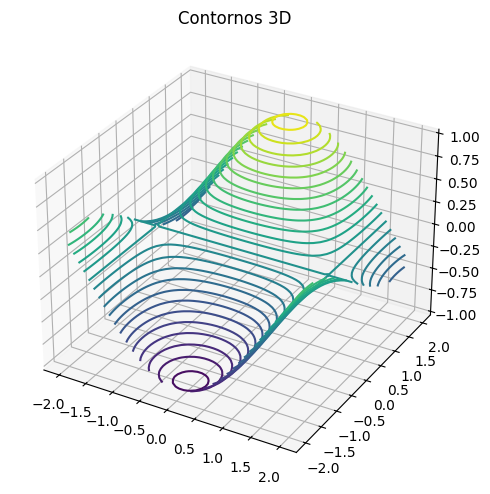

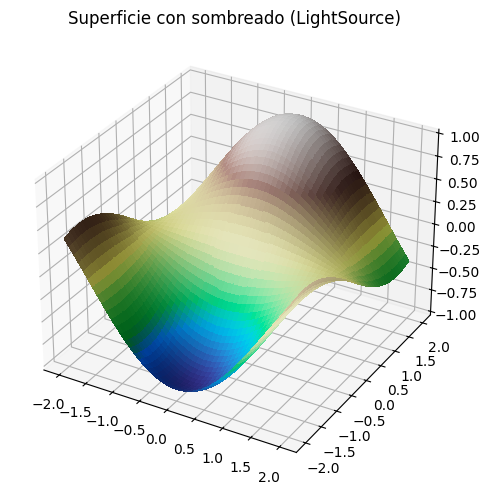

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, layout="constrained")
X, Y = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
Z = np.cos(X) * np.sin(Y)
ax.plot_wireframe(X, Y, Z, rstride=2, cstride=2)
ax.set_title("Wireframe 3D")
plt.show()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, layout="constrained")
ax.contour3D(X, Y, Z, levels=25, cmap="viridis")
ax.set_title("Contornos 3D")
plt.show()

from matplotlib.colors import LightSource

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, layout="constrained")
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=plt.get_cmap("terrain"), vert_exag=1.0, blend_mode="soft")
ax.plot_surface(X, Y, Z, facecolors=rgb, linewidth=0, antialiased=False)
ax.set_title("Superficie con sombreado (LightSource)")
plt.show()

11.3 Aplicaciones en ciencia de datos
Exploración de variables: cuando tenés tres atributos clave, un scatter 3D coloreado por clase permite inspeccionar separabilidad antes de entrenar un modelo.

Clustering: graficá las etiquetas de algoritmos como K-Means o DBSCAN para confirmar si los grupos están bien definidos o si existen solapamientos.

Regresión: compará la superficie predicha z = f(x, y) frente a los datos reales para detectar desviaciones o zonas mal ajustadas.

Reducción de dimensionalidad: al proyectar PCA/UMAP/t-SNE a tres dimensiones, el plot 3D ayuda a ubicar outliers y a entender la estructura global.

Datos geoespaciales: mallas de terreno, LiDAR o point clouds se benefician de superficies y sombreado para percibir relieve y densidad.

Sensores y series multivariadas: mapear (tiempo, variable1, variable2) como hélices u otras trayectorias evidencia ciclos, fases o anomalías.

⚡ Buenas prácticas: controlá la cámara con view_init, agregá colorbar cuando muestres magnitudes continuas y ajustá alpha o tamaños de marcador para evitar ruido visual.